In [37]:
import pandas as pd
import numpy as np
import umap
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import time
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# Reduce NUM_RANDOM_STATES for a quick test run (e.g. 10);
# set to 100 for the full experiment as described.
# N_REMOVALS × ROWS_PER_STEP must not exceed the dataset size (446 rows).
NUM_RANDOM_STATES = 100  # random seeds 1 … NUM_RANDOM_STATES
N_REMOVALS        = 100   # number of removal steps  (80 × 5 = 400 rows removed)
ROWS_PER_STEP     = 1    # rows dropped at each step

FEATURES_CSV = "../data/features.csv"
RESULTS_CSV  = "stability_results.csv"
OUTPUT_PNG   = "stability_vs_dataset_size.png"
# ──────────────────────────────────────────────────────────────────────────────

In [38]:
# ── Load + preprocess ─────────────────────────────────────────────────────────
# Preprocessing mirrors UMAP_HDBSCAN.ipynb:
#   • drop file_name
#   • map boolean strings → 0/1
#   • coerce everything to numeric, drop fully-non-numeric columns
#   • impute residual NaNs with column mean

df_original = pd.read_csv(FEATURES_CSV)
print(f"Loaded {len(df_original)} rows, {len(df_original.columns)} columns")

def preprocess(df: pd.DataFrame) -> np.ndarray:
    """Return a scaled numpy array ready for UMAP, leaving df unchanged."""
    X = df.drop(columns=["file_name"], errors="ignore").copy()
    X = X.replace({'True': 1, 'False': 0, True: 1, False: 0})
    X = X.apply(pd.to_numeric, errors='coerce')
    all_nan_cols = X.columns[X.isna().all()].tolist()
    if all_nan_cols:
        X = X.drop(columns=all_nan_cols)
    X = X.fillna(X.mean())
    return StandardScaler().fit_transform(X)

Loaded 446 rows, 72 columns


In [39]:
# ── UMAP / HDBSCAN parameters (identical to UMAP_HDBSCAN.ipynb) ───────────────
UMAP_PARAMS = dict(
    n_neighbors  = 10,
    min_dist     = 0.001, #.001
    n_components = 3,
    metric       = "euclidean",
)

HDBSCAN_PARAMS = dict(
    min_cluster_size = 30,
    min_samples      = 5,
    metric           = "euclidean",
)

def cluster_once(X_scaled: np.ndarray, random_state: int) -> np.ndarray:
    """Run one UMAP embedding + HDBSCAN and return cluster labels."""
    embedding = umap.UMAP(**UMAP_PARAMS, random_state=random_state).fit_transform(X_scaled)
    return hdbscan.HDBSCAN(**HDBSCAN_PARAMS).fit_predict(embedding)


def mean_pairwise_ari(label_matrix: list) -> tuple[float, float]:
    """
    Compute mean (and std) Adjusted Rand Index across all C(n, 2) pairs
    of clustering runs.  Returns (mean_ari, std_ari).
    """
    scores = [
        adjusted_rand_score(a, b)
        for a, b in combinations(label_matrix, 2)
    ]
    return float(np.mean(scores)), float(np.std(scores))

In [40]:
# ── Runtime estimate ──────────────────────────────────────────────────────────
# Time a single UMAP fit on the full dataset so we can predict total runtime
# before committing to the full loop.

_X_sample = preprocess(df_original)
_t0 = time.perf_counter()
cluster_once(_X_sample, random_state=1)
_single_fit_s = time.perf_counter() - _t0

total_fits     = (N_REMOVALS + 1) * NUM_RANDOM_STATES
estimated_mins = total_fits * _single_fit_s / 60

print(f"Single UMAP+HDBSCAN fit : {_single_fit_s:.2f}s")
print(f"Removal schedule        : {N_REMOVALS} steps × {ROWS_PER_STEP} rows = {N_REMOVALS * ROWS_PER_STEP} rows removed total")
print(f"Total fits              : {total_fits:,}  ({N_REMOVALS+1} sizes × {NUM_RANDOM_STATES} seeds)")
print(f"Estimated runtime       : {estimated_mins:.0f} min  ({estimated_mins/60:.1f} h)")
print()
print("Reduce NUM_RANDOM_STATES or N_REMOVALS in Cell 0 if the estimate is too long.")

Single UMAP+HDBSCAN fit : 1.06s
Removal schedule        : 100 steps × 1 rows = 100 rows removed total
Total fits              : 10,100  (101 sizes × 100 seeds)
Estimated runtime       : 178 min  (3.0 h)

Reduce NUM_RANDOM_STATES or N_REMOVALS in Cell 0 if the estimate is too long.


In [41]:
# ── Main experiment loop ──────────────────────────────────────────────────────
# For each dataset size (full → full - N_REMOVALS*ROWS_PER_STEP rows):
#   1. Preprocess + scale
#   2. Run UMAP+HDBSCAN for each random state 1 … NUM_RANDOM_STATES
#   3. Compute mean pairwise ARI across all pairs of runs
#   4. Drop ROWS_PER_STEP random rows (reproducibly) and repeat

random_states = list(range(1, NUM_RANDOM_STATES + 1))
df_working    = df_original.copy()
results       = []

outer_bar = tqdm(range(N_REMOVALS + 1), desc="Dataset sizes", unit="size")

for step in outer_bar:
    n_points = len(df_working)

    # Safety guard: stop if too few points remain for meaningful clustering
    if n_points < HDBSCAN_PARAMS["min_cluster_size"] * 2:
        print(f"\nStopped at step {step}: only {n_points} rows remain "
              f"(< 2 × min_cluster_size={HDBSCAN_PARAMS['min_cluster_size']}).")
        break

    X_scaled = preprocess(df_working)

    # Collect one label array per random state
    all_labels = []
    for rs in random_states:
        all_labels.append(cluster_once(X_scaled, rs))

    mean_ari, std_ari = mean_pairwise_ari(all_labels)

    # Fraction of points labeled as noise (-1) averaged across runs
    noise_fracs = [np.mean(lbl == -1) for lbl in all_labels]
    mean_noise  = float(np.mean(noise_fracs))

    results.append({
        "n_removed" : step * ROWS_PER_STEP,
        "n_points"  : n_points,
        "mean_ari"  : mean_ari,
        "std_ari"   : std_ari,
        "mean_noise": mean_noise,
    })

    outer_bar.set_postfix(n=n_points, ari=f"{mean_ari:.3f}", noise=f"{mean_noise:.2%}")

    # Drop ROWS_PER_STEP random rows (use step as seed for reproducibility)
    if step < N_REMOVALS:
        drop_idx   = df_working.sample(ROWS_PER_STEP, random_state=step).index
        df_working = df_working.drop(index=drop_idx).reset_index(drop=True)


results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\nSaved results → {RESULTS_CSV}")
results_df.head(10)

Dataset sizes:   0%|          | 0/101 [00:00<?, ?size/s]


Saved results → stability_results.csv


,n_removed,n_points,mean_ari,std_ari,mean_noise
0,0,446,0.964679,0.057098,0.056390
1,1,445,0.954487,0.094226,0.056584
2,2,444,0.958032,0.050254,0.049234
3,3,443,0.976629,0.055097,0.057517
4,4,442,0.959195,0.065433,0.048100
5,5,441,0.956315,0.050462,0.040363
6,6,440,0.975096,0.062430,0.052591
7,7,439,0.979791,0.035246,0.053941
8,8,438,0.946332,0.085560,0.052763
9,9,437,0.969234,0.072144,0.053112


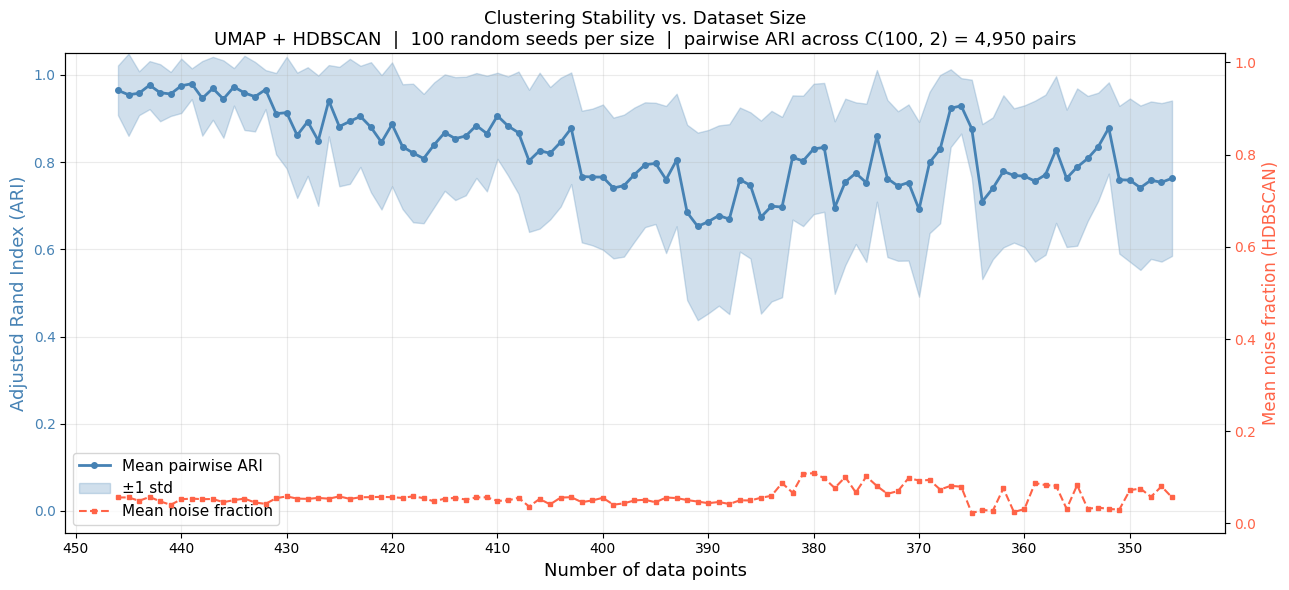

Saved plot → stability_vs_dataset_size.png


In [42]:
# ── Visualization ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))

x     = results_df["n_points"]
y     = results_df["mean_ari"]
y_std = results_df["std_ari"]

# Primary: mean ARI ± 1 std
ax1.plot(x, y, color="steelblue", linewidth=2, marker="o", markersize=4, label="Mean pairwise ARI")
ax1.fill_between(x, y - y_std, y + y_std, alpha=0.25, color="steelblue", label="±1 std")

ax1.set_xlabel("Number of data points", fontsize=13)
ax1.set_ylabel("Adjusted Rand Index (ARI)", fontsize=13, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(-0.05, 1.05)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(True, alpha=0.25)
ax1.invert_xaxis()   # left = full dataset, right = most data removed

# Secondary: mean noise fraction
ax2 = ax1.twinx()
ax2.plot(x, results_df["mean_noise"], color="tomato", linewidth=1.5,
         linestyle="--", marker="s", markersize=3, label="Mean noise fraction")
ax2.set_ylabel("Mean noise fraction (HDBSCAN)", fontsize=12, color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")
ax2.set_ylim(-0.02, 1.02)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=11)

ax1.set_title(
    f"Clustering Stability vs. Dataset Size\n"
    f"UMAP + HDBSCAN  |  {NUM_RANDOM_STATES} random seeds per size  |  "
    f"pairwise ARI across C({NUM_RANDOM_STATES}, 2) = {len(list(combinations(range(NUM_RANDOM_STATES), 2))):,} pairs",
    fontsize=13,
)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
plt.show()
print(f"Saved plot → {OUTPUT_PNG}")